In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro, ttest_1samp, ttest_ind
from scipy.stats import mannwhitneyu, f_oneway, kruskal
from scipy.stats import chi2_contingency, pearsonr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("blr_aqi.csv")

In [3]:
df.head()

,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi
0,2022-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-08-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-08-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-08-04,15.242105,10.647368,288.894737,17.910526,4.484211,44.052632,0.19,0.0,0.781579,NaN,NaN
4,2022-08-05,6.137500,4.295833,170.750000,10.245833,2.041667,37.791667,0.05,0.0,0.381250,28.789474,15.263158


In [4]:
df.tail()

,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi
1293,2026-02-14,18.491667,18.091667,411.583333,10.391667,6.037500,92.375000,0.119167,0.083333,2.620833,60.000000,39.666667
1294,2026-02-15,38.187500,37.225000,496.458333,20.950000,13.308333,114.791667,0.254583,1.375000,2.462500,91.458333,58.708333
1295,2026-02-16,46.587500,45.420833,472.375000,10.862500,14.216667,135.416667,0.428333,1.875000,2.327083,118.333333,72.291667
1296,2026-02-17,38.275000,37.441667,464.458333,10.212500,13.937500,130.708333,0.386667,1.416667,2.445833,123.666667,75.333333
1297,2026-02-18,22.191667,21.370833,476.166667,12.208333,10.970833,108.750000,0.203333,1.083333,2.512500,86.833333,60.375000


In [6]:
df.shape

(1298, 12)

In [8]:
df['date'] = pd.to_datetime(df['date'])

In [9]:
df = df.drop_duplicates()

In [10]:
df = df.dropna(subset=['us_aqi'])

In [11]:
df.isnull().sum()

date                     0
pm10                     0
pm2_5                    0
carbon_monoxide          0
nitrogen_dioxide         0
sulphur_dioxide          0
ozone                    0
aerosol_optical_depth    0
dust                     0
uv_index                 0
us_aqi                   0
european_aqi             0
dtype: int64

In [13]:
print("Mean AQI:", df['us_aqi'].mean())
print("Median AQI:", df['us_aqi'].median())
print("Standard Deviation:", df['us_aqi'].std())
print("Minimum AQI:", df['us_aqi'].min())
print("Maximum AQI:", df['us_aqi'].max())

Mean AQI: 68.87187491526342
Median AQI: 69.58333333333334
Standard Deviation: 31.91822542941418
Minimum AQI: 14.833333333333334
Maximum AQI: 155.58333333333334


In [36]:
variance = df['us_aqi'].var()
print("Variance:", variance)

Variance: 1018.7731145629018


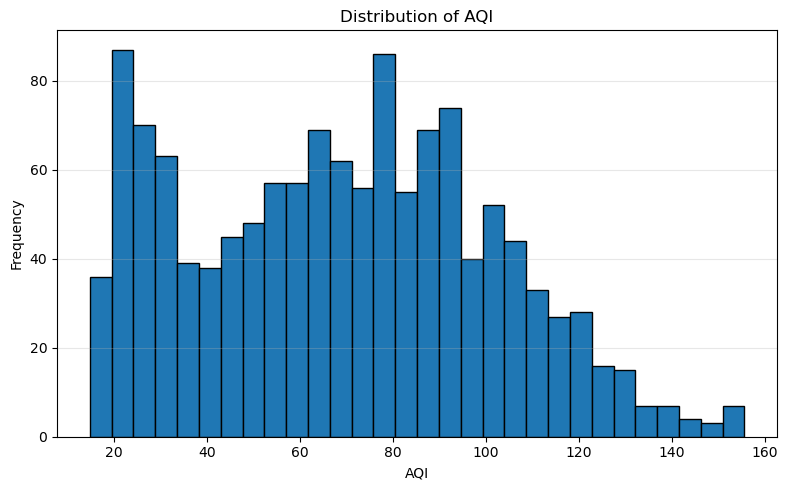

In [14]:
plt.figure(figsize=(8,5))
plt.hist(
    df['us_aqi'],
    bins=30,
    edgecolor='black')
plt.title("Distribution of AQI")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
df['AQI_Category'] = pd.cut(
    df['us_aqi'],
    bins=[-1, 50, 100, 150, 200, 300, np.inf],
    labels=[
        'Good',
        'Moderate',
        'Unhealthy for Sensitive Groups',
        'Unhealthy',
        'Very Unhealthy',
        'Hazardous'
    ]
)

print("\n========== AQI CATEGORY ==========")

print(df['AQI_Category'].value_counts().sort_index())

print("\nPercentage:")
print(
    (df['AQI_Category']
     .value_counts(normalize=True)
     .sort_index() * 100).round(2)
)



========== AQI CATEGORY ==========
AQI_Category
Good                              400
Moderate                          657
Unhealthy for Sensitive Groups    230
Unhealthy                           7
Very Unhealthy                      0
Hazardous                           0
Name: count, dtype: int64

Percentage:
AQI_Category
Good                              30.91
Moderate                          50.77
Unhealthy for Sensitive Groups    17.77
Unhealthy                          0.54
Very Unhealthy                     0.00
Hazardous                          0.00
Name: proportion, dtype: float64


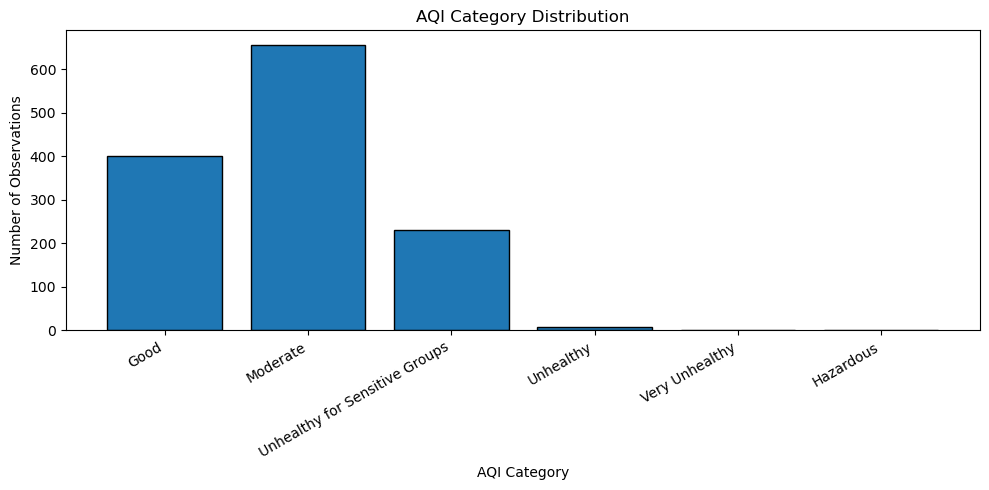

In [20]:
category_count = df['AQI_Category'].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.bar(
    category_count.index.astype(str),
    category_count.values,
    edgecolor='black'
)

plt.title("AQI Category Distribution")
plt.xlabel("AQI Category")
plt.ylabel("Number of Observations")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [21]:
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

monthly_aqi = df.groupby('month')['us_aqi'].mean()

months = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

print("\n========== MONTHLY AQI ==========")

monthly_table = pd.DataFrame({
    'Month': months,
    'Average AQI': monthly_aqi.reindex(range(1,13)).values
})

print(monthly_table.round(2))


========== MONTHLY AQI ==========
        Month  Average AQI
0     January        92.56
1    February        86.46
2       March        88.63
3       April        91.06
4         May        80.38
5        June        41.80
6        July        23.87
7      August        41.78
8   September        41.31
9     October        74.86
10   November        79.40
11   December        81.14


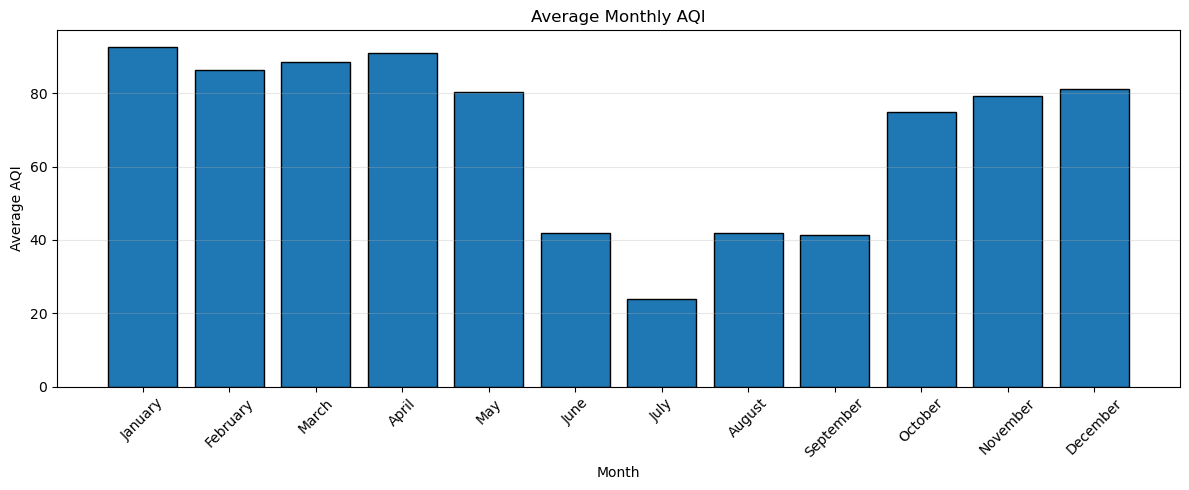

In [22]:
plt.figure(figsize=(12,5))

plt.bar(
    months,
    monthly_aqi.reindex(range(1,13)),
    edgecolor='black'
)

plt.title("Average Monthly AQI")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
highest_month = monthly_table.loc[
    monthly_table['Average AQI'].idxmax()
]

lowest_month = monthly_table.loc[
    monthly_table['Average AQI'].idxmin()
]

print("\nHighest AQI Month:")
print(highest_month)

print("\nLowest AQI Month:")
print(lowest_month)


Highest AQI Month:
Month           January
Average AQI    92.55914
Name: 0, dtype: object

Lowest AQI Month:
Month               July
Average AQI    23.866487
Name: 6, dtype: object



========== YEARLY AQI ==========
year
2022    65.61
2023    68.85
2024    64.71
2025    70.56
2026    97.44
Name: us_aqi, dtype: float64


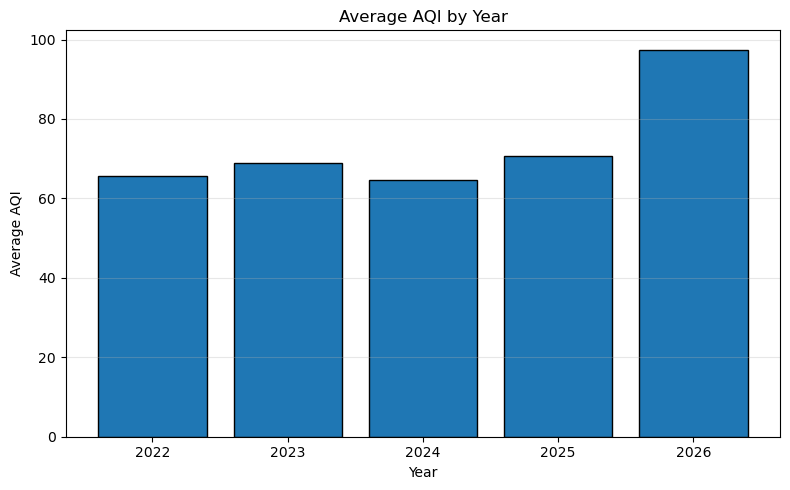

In [24]:
yearly_aqi = df.groupby('year')['us_aqi'].mean()

print("\n========== YEARLY AQI ==========")
print(yearly_aqi.round(2))


plt.figure(figsize=(8,5))

plt.bar(
    yearly_aqi.index.astype(str),
    yearly_aqi.values,
    edgecolor='black'
)

plt.title("Average AQI by Year")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


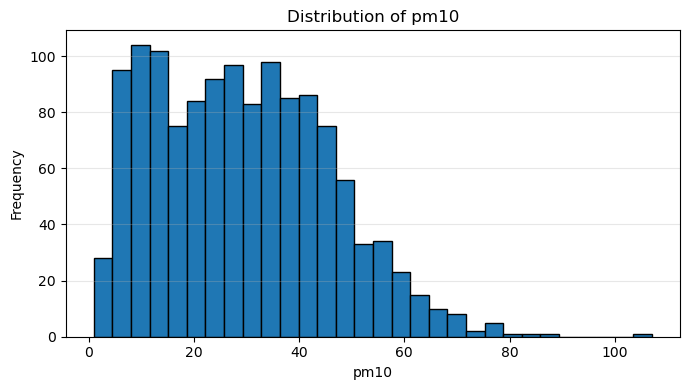

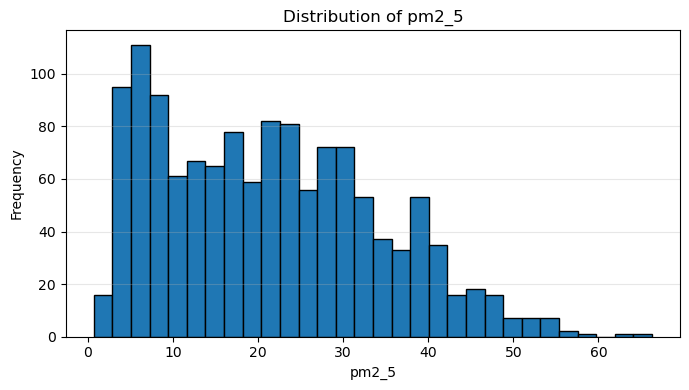

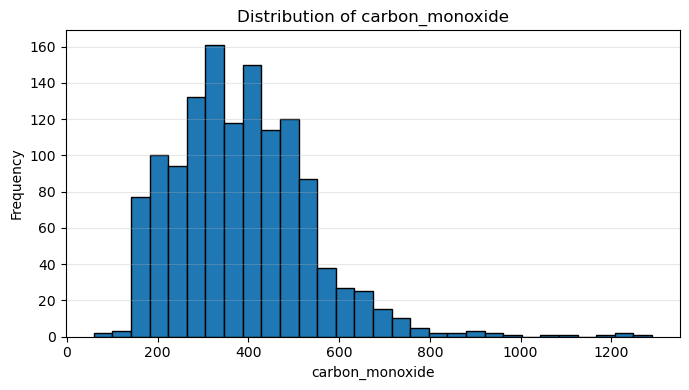

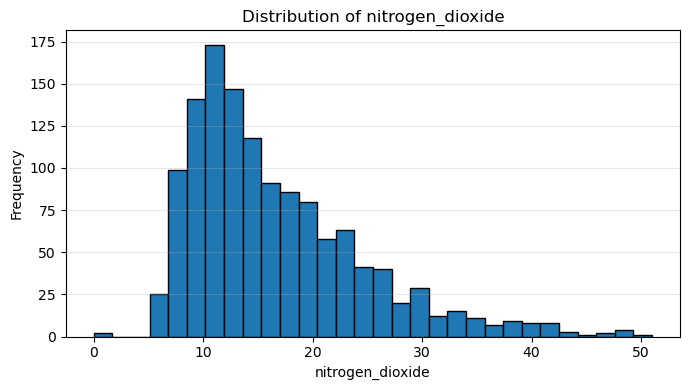

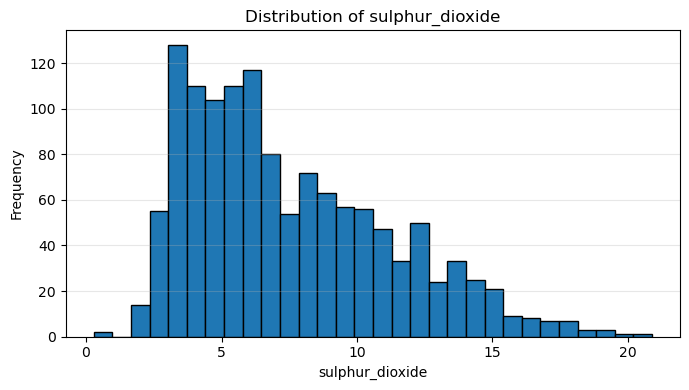

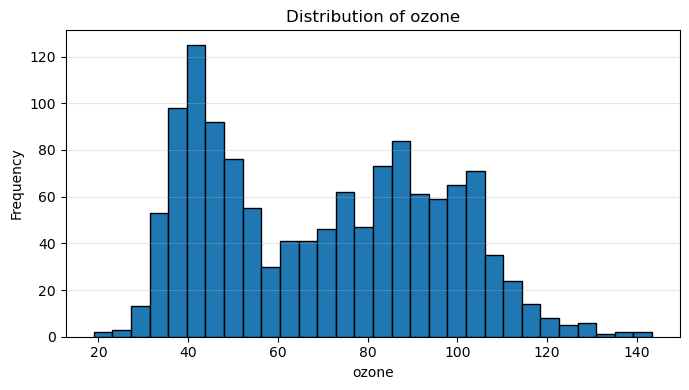

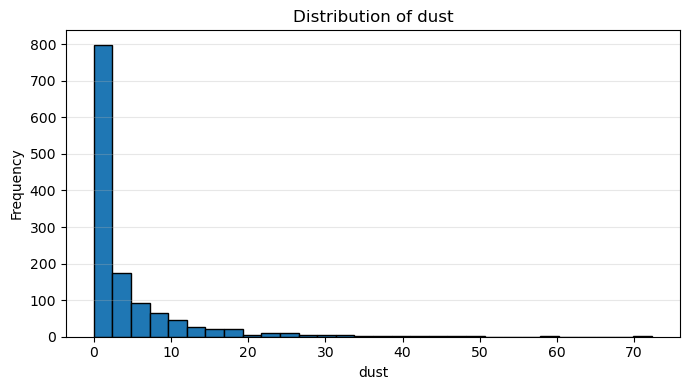

In [25]:
pollutants = [
    'pm10',
    'pm2_5',
    'carbon_monoxide',
    'nitrogen_dioxide',
    'sulphur_dioxide',
    'ozone',
    'dust'
]

for col in pollutants:

    if col in df.columns:

        plt.figure(figsize=(7,4))

        plt.hist(
            df[col].dropna(),
            bins=30,
            edgecolor='black'
        )

        plt.title("Distribution of " + col)
        plt.xlabel(col)
        plt.ylabel("Frequency")

        plt.grid(axis='y', alpha=0.3)

        plt.tight_layout()
        plt.show()

In [26]:
print("POLLUTANT STATISTICS")

print(
    df[pollutants].describe().round(2)
)


POLLUTANT STATISTICS
          pm10    pm2_5  carbon_monoxide  nitrogen_dioxide  sulphur_dioxide  \
count  1294.00  1294.00          1294.00           1294.00          1294.00   
mean     29.23    21.28           385.99             16.60             7.50   
std      16.56    12.73           150.69              7.98             3.72   
min       0.99     0.70            59.04              0.00             0.29   
25%      14.86     9.81           284.18             10.77             4.48   
50%      28.33    20.53           371.40             14.51             6.54   
75%      41.03    30.12           475.92             20.64             9.95   
max     107.10    66.30          1289.88             51.00            20.89   

         ozone     dust  
count  1294.00  1294.00  
mean     69.95     4.07  
std      25.77     7.08  
min      18.96     0.00  
25%      45.14     0.17  
50%      70.52     1.21  
75%      90.90     4.78  
max     143.38    72.33  


In [27]:

for col in pollutants:

    if col in df.columns:

        data = df[['us_aqi', col]].dropna()

        r, p = pearsonr(
            data['us_aqi'],
            data[col]
        )

        print(
            col,
            "Correlation =", round(r,3),
            "p-value =", round(p,4)
        )



pm10 Correlation = 0.892 p-value = 0.0
pm2_5 Correlation = 0.954 p-value = 0.0
carbon_monoxide Correlation = 0.693 p-value = 0.0
nitrogen_dioxide Correlation = 0.539 p-value = 0.0
sulphur_dioxide Correlation = 0.71 p-value = 0.0
ozone Correlation = 0.803 p-value = 0.0
dust Correlation = -0.03 p-value = 0.2816


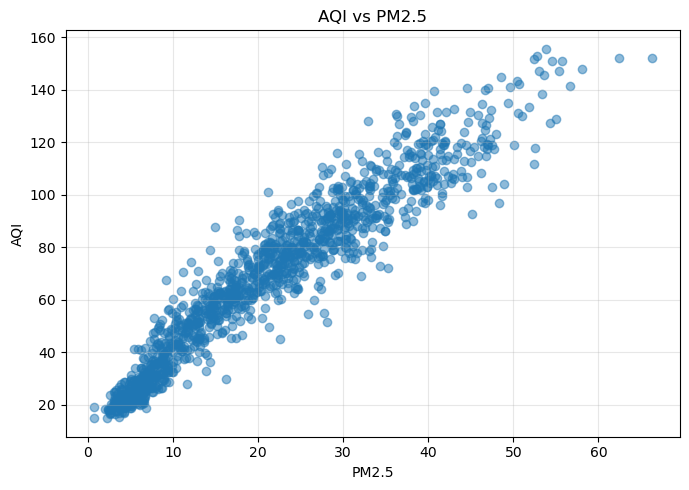

In [28]:
if 'pm2_5' in df.columns:

    data = df[['us_aqi','pm2_5']].dropna()

    plt.figure(figsize=(7,5))

    plt.scatter(
        data['pm2_5'],
        data['us_aqi'],
        alpha=0.5
    )

    plt.title("AQI vs PM2.5")
    plt.xlabel("PM2.5")
    plt.ylabel("AQI")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


In [29]:
sample = df['us_aqi'].dropna()

# Use maximum 5000 observations for Shapiro
sample = sample.sample(
    min(len(sample), 5000),
    random_state=1
)

stat, p = shapiro(sample)

print("\n========== SHAPIRO-WILK TEST ==========")
print("Statistic:", stat)
print("p-value:", p)

if p < 0.05:
    print("Decision: Reject H0")
    print("AQI is not normally distributed.")
else:
    print("Decision: Fail to reject H0")
    print("AQI is approximately normally distributed.")


========== SHAPIRO-WILK TEST ==========
Statistic: 0.9721269683119947
p-value: 4.228503892036941e-15
Decision: Reject H0
AQI is not normally distributed.


In [30]:
stat, p = ttest_1samp(
    df['us_aqi'].dropna(),
    100
)

print("\n========== ONE SAMPLE T-TEST ==========")
print("Statistic:", stat)
print("p-value:", p)

if p < 0.05:
    print("Reject H0: Mean AQI is significantly different from 100.")
else:
    print("Fail to reject H0: No significant difference from 100.")


========== ONE SAMPLE T-TEST ==========
Statistic: -35.08175921421521
p-value: 5.362681541787888e-190
Reject H0: Mean AQI is significantly different from 100.


In [31]:
mid = len(df) // 2

group1 = df['us_aqi'].iloc[:mid]
group2 = df['us_aqi'].iloc[mid:]

stat, p = ttest_ind(
    group1,
    group2,
    equal_var=False
)

print("\n========== INDEPENDENT T-TEST ==========")
print("Statistic:", stat)
print("p-value:", p)

if p < 0.05:
    print("Reject H0: The two periods are significantly different.")
else:
    print("Fail to reject H0.")



========== INDEPENDENT T-TEST ==========
Statistic: 1.9305721181078905
p-value: 0.05377199050114732
Fail to reject H0.


In [32]:
table = pd.crosstab(
    df['year'],
    df['AQI_Category']
)

chi, p, dof, expected = chi2_contingency(table)

print("\n========== CHI-SQUARE TEST ==========")
print("Chi-square:", chi)
print("p-value:", p)
print("Degrees of freedom:", dof)

if p < 0.05:
    print("Reject H0: AQI category is associated with year.")
else:
    print("Fail to reject H0.")


========== CHI-SQUARE TEST ==========
Chi-square: 85.81418344293138
p-value: 3.1734619870052994e-13
Degrees of freedom: 12
Reject H0: AQI category is associated with year.


In [33]:
features = [
    'pm10',
    'pm2_5',
    'carbon_monoxide',
    'nitrogen_dioxide',
    'sulphur_dioxide',
    'ozone',
    'dust'
]

features = [
    x for x in features
    if x in df.columns
]

reg_data = df[
    features + ['us_aqi']
].dropna()

X = reg_data[features]
y = reg_data['us_aqi']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

prediction = model.predict(X_test)

r2 = r2_score(
    y_test,
    prediction
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        prediction
    )
)

print("\n========== REGRESSION ==========")

print("R-squared:", round(r2,4))
print("RMSE:", round(rmse,4))

print("\nCoefficients:")

for name, coef in zip(
    features,
    model.coef_
):
    print(
        name,
        ":", round(coef,4)
    )




========== REGRESSION ==========
R-squared: 0.9292
RMSE: 8.196

Coefficients:
pm10 : -0.0112
pm2_5 : 1.821
carbon_monoxide : 0.0008
nitrogen_dioxide : 0.3601
sulphur_dioxide : 0.0405
ozone : 0.2931
dust : 0.0427


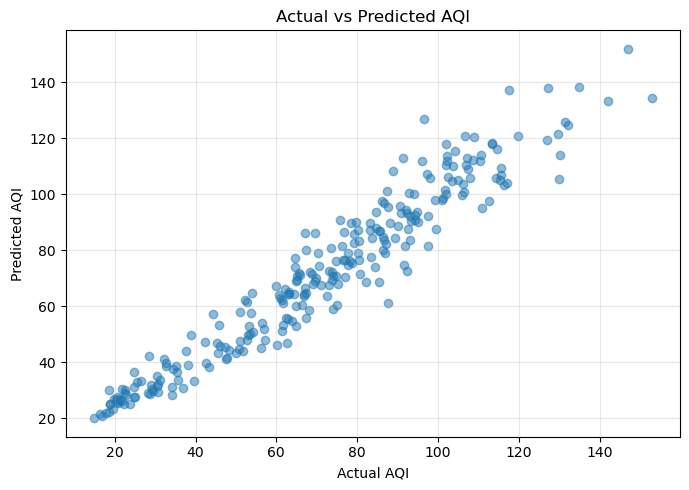

In [34]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    prediction,
    alpha=0.5
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

plt.title(
    "Actual vs Predicted AQI"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
print("\n======================================")
print("       FINAL PROJECT SUMMARY")
print("======================================")

print("Number of observations:", len(df))

print(
    "Mean AQI:",
    round(df['us_aqi'].mean(),2)
)

print(
    "Minimum AQI:",
    df['us_aqi'].min()
)

print(
    "Maximum AQI:",
    df['us_aqi'].max()
)

print(
    "Highest AQI Month:",
    highest_month['Month']
)

print(
    "Lowest AQI Month:",
    lowest_month['Month']
)

print(
    "Most Common AQI Category:",
    df['AQI_Category'].value_counts().idxmax()
)

print(
    "Regression R²:",
    round(r2,4)
)


       FINAL PROJECT SUMMARY
Number of observations: 1294
Mean AQI: 68.87
Minimum AQI: 14.833333333333334
Maximum AQI: 155.58333333333334
Highest AQI Month: January
Lowest AQI Month: July
Most Common AQI Category: Moderate
Regression R²: 0.9292


In [38]:
# MULTIPLE LINEAR REGRESSION

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Load dataset
df = pd.read_csv("blr_aqi.csv")

# Select variables
features = [
    'pm10',
    'pm2_5',
    'carbon_monoxide',
    'nitrogen_dioxide',
    'sulphur_dioxide',
    'ozone',
    'dust'
]

# Remove missing values
data = df[features + ['us_aqi']].dropna()

# X = independent variables
X = data[features]

# y = dependent variable
y = data['us_aqi']

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict AQI
y_pred = model.predict(X_test)

# R-squared
r2 = r2_score(y_test, y_pred)

# Number of observations and predictors
n = len(y_test)
p = X_test.shape[1]

# Adjusted R-squared
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# Display results
print("MULTIPLE LINEAR REGRESSION RESULTS")
print("-----------------------------------")

print("R²:", round(r2, 3))
print("Adjusted R²:", round(adjusted_r2, 3))
print("MSE:", round(mse, 2))
print("RMSE:", round(rmse, 2))

MULTIPLE LINEAR REGRESSION RESULTS
-----------------------------------
R²: 0.929
Adjusted R²: 0.927
MSE: 67.17
RMSE: 8.2


In [39]:
print("\nRegression Equation:")

print("AQI =", round(model.intercept_, 3), end=" ")

for name, coef in zip(features, model.coef_):
    print(
        f"+ ({coef:.3f} × {name})",
        end=" "
    )


Regression Equation:
AQI = 3.276 + (-0.011 × pm10) + (1.821 × pm2_5) + (0.001 × carbon_monoxide) + (0.360 × nitrogen_dioxide) + (0.041 × sulphur_dioxide) + (0.293 × ozone) + (0.043 × dust) 

Regression Coefficients
-----------------------
pm10 : 0.0032
pm2_5 : 1.7913
carbon_monoxide : 0.0005
nitrogen_dioxide : 0.3734
sulphur_dioxide : -0.0024
ozone : 0.3007
dust : 0.0519

Intercept: 3.0318

Coefficient Table:
          Pollutant  Coefficient
0              pm10       0.0032
1             pm2_5       1.7913
2   carbon_monoxide       0.0005
3  nitrogen_dioxide       0.3734
4   sulphur_dioxide      -0.0024
5             ozone       0.3007
6              dust       0.0519


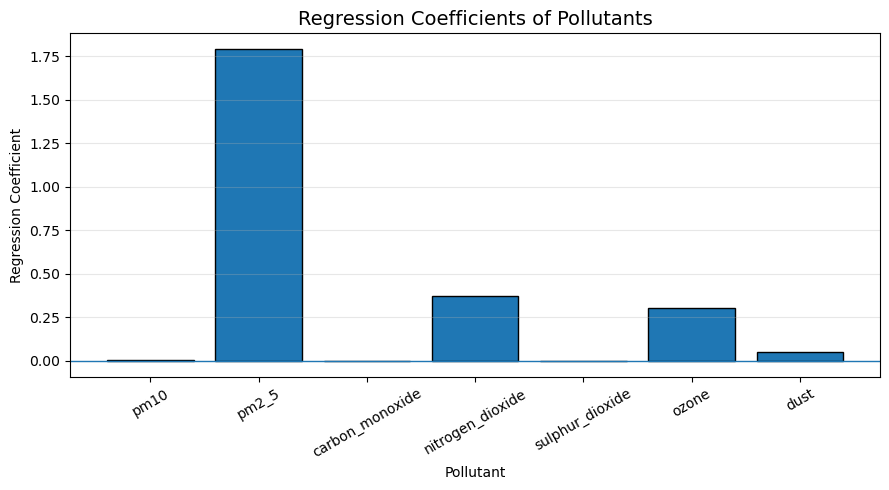

In [41]:
# REGRESSION COEFFICIENTS

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv("blr_aqi.csv")

# Independent variables
features = [
    'pm10',
    'pm2_5',
    'carbon_monoxide',
    'nitrogen_dioxide',
    'sulphur_dioxide',
    'ozone',
    'dust'
]

# Remove missing values
data = df[features + ['us_aqi']].dropna()

# X and Y
X = data[features]
y = data['us_aqi']

# Create and fit model
model = LinearRegression()
model.fit(X, y)

# Regression coefficients
print("Regression Coefficients")
print("-----------------------")

for variable, coefficient in zip(features, model.coef_):
    print(variable, ":", round(coefficient, 4))

# Intercept
print("\nIntercept:", round(model.intercept_, 4))


# Create coefficient table
coefficient_table = pd.DataFrame({
    'Pollutant': features,
    'Coefficient': model.coef_
})

print("\nCoefficient Table:")
print(coefficient_table.round(4))


# Plot coefficients
plt.figure(figsize=(9, 5))

plt.bar(
    coefficient_table['Pollutant'],
    coefficient_table['Coefficient'],
    edgecolor='black'
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "Regression Coefficients of Pollutants",
    fontsize=14
)

plt.xlabel("Pollutant")
plt.ylabel("Regression Coefficient")

plt.xticks(rotation=30)

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "regression_coefficients.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

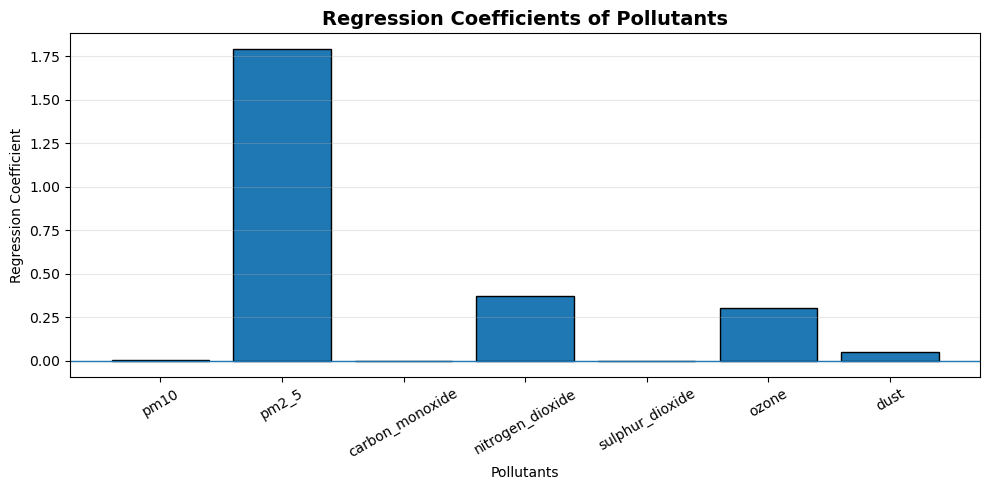

In [42]:
import matplotlib.pyplot as plt

# Regression coefficients from your model
coefficients = model.coef_

plt.figure(figsize=(10, 5))

plt.bar(
    features,
    coefficients,
    edgecolor='black'
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title(
    "Regression Coefficients of Pollutants",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Pollutants")
plt.ylabel("Regression Coefficient")

plt.xticks(rotation=30)

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "regression_coefficients.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [45]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_csv("blr_aqi.csv")

df['date'] = pd.to_datetime(df['date'])

# Remove duplicates and missing AQI
df = df.drop_duplicates()
df = df.dropna(subset=['us_aqi'])

# Create month and year
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year


# =====================================================
# AQI CATEGORY
# =====================================================

df['AQI_Category'] = pd.cut(
    df['us_aqi'],
    bins=[-1, 50, 100, 150, 200, 300, np.inf],
    labels=[
        'Good',
        'Moderate',
        'Unhealthy for Sensitive Groups',
        'Unhealthy',
        'Very Unhealthy',
        'Hazardous'
    ]
)


# =====================================================
# 1. MEAN AQI
# =====================================================

mean_aqi = df['us_aqi'].mean()


# =====================================================
# 2. HIGHEST AQI MONTH
# =====================================================

monthly_aqi = df.groupby('month')['us_aqi'].mean()

month_names = {
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
}

highest_month_number = monthly_aqi.idxmax()
lowest_month_number = monthly_aqi.idxmin()

highest_month = month_names[highest_month_number]
lowest_month = month_names[lowest_month_number]


# =====================================================
# 3. MOST FREQUENT AQI CATEGORY
# =====================================================

most_common_category = (
    df['AQI_Category']
    .value_counts()
    .idxmax()
)


# =====================================================
# 4. STRONGEST AQI-POLLUTANT CORRELATION
# =====================================================

pollutants = [
    'pm10',
    'pm2_5',
    'carbon_monoxide',
    'nitrogen_dioxide',
    'sulphur_dioxide',
    'ozone',
    'dust'
]

correlations = {}

for pollutant in pollutants:

    if pollutant in df.columns:

        data = df[['us_aqi', pollutant]].dropna()

        r, p = pearsonr(
            data['us_aqi'],
            data[pollutant]
        )

        correlations[pollutant] = r

# Strongest correlation based on absolute value
strongest_pollutant = max(
    correlations,
    key=lambda x: abs(correlations[x])
)

strongest_correlation = correlations[
    strongest_pollutant
]


# =====================================================
# 5. AQI OUTLIERS
# USING IQR METHOD
# =====================================================

Q1 = df['us_aqi'].quantile(0.25)
Q3 = df['us_aqi'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df['us_aqi'] < lower_limit) |
    (df['us_aqi'] > upper_limit)
]

number_of_outliers = len(outliers)


# =====================================================
# 6. MULTIPLE LINEAR REGRESSION R²
# =====================================================

features = [
    'pm10',
    'pm2_5',
    'carbon_monoxide',
    'nitrogen_dioxide',
    'sulphur_dioxide',
    'ozone',
    'dust'
]

# Keep only columns that exist
features = [
    x for x in features
    if x in df.columns
]

reg_data = df[
    features + ['us_aqi']
].dropna()

X = reg_data[features]
y = reg_data['us_aqi']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

y_pred = model.predict(X_test)

r2 = r2_score(
    y_test,
    y_pred
)


# =====================================================
# 7. SIGNIFICANT YEARLY DIFFERENCE
# ANOVA
# =====================================================

from scipy.stats import f_oneway

year_groups = []

for year in sorted(df['year'].unique()):

    values = df[
        df['year'] == year
    ]['us_aqi'].dropna()

    if len(values) > 1:
        year_groups.append(values)

if len(year_groups) >= 2:

    statistic, yearly_p = f_oneway(
        *year_groups
    )

    if yearly_p < 0.05:
        yearly_difference = "Yes"
    else:
        yearly_difference = "No"

else:

    yearly_difference = "Not enough data"


# =====================================================
# 8. SIGNIFICANT MONTHLY DIFFERENCE
# KRUSKAL-WALLIS TEST
# =====================================================

from scipy.stats import kruskal

month_groups = []

for month in range(1, 13):

    values = df[
        df['month'] == month
    ]['us_aqi'].dropna()

    if len(values) > 1:
        month_groups.append(values)

if len(month_groups) >= 2:

    statistic, monthly_p = kruskal(
        *month_groups
    )

    if monthly_p < 0.05:
        monthly_difference = "Yes"
    else:
        monthly_difference = "No"

else:

    monthly_difference = "Not enough data"


# =====================================================
# 9. AQI CATEGORY-YEAR ASSOCIATION
# CHI-SQUARE TEST
# =====================================================

from scipy.stats import chi2_contingency

table = pd.crosstab(
    df['year'],
    df['AQI_Category']
)

chi_square, category_year_p, dof, expected = (
    chi2_contingency(table)
)

if category_year_p < 0.05:
    category_year_association = "Yes"
else:
    category_year_association = "No"


# =====================================================
# FINAL DASHBOARD VALUES
# =====================================================

print("\n==============================================")
print("       BENGALURU AQI KEY INSIGHTS")
print("==============================================")

print(
    f"Mean AQI                  : {mean_aqi:.2f}"
)

print(
    f"Highest AQI month         : {highest_month}"
)

print(
    f"Lowest AQI month          : {lowest_month}"
)

print(
    f"Most frequent AQI category: {most_common_category}"
)

print(
    f"Strongest AQI pollutant   : {strongest_pollutant}"
)

print(
    f"Correlation               : {strongest_correlation:.3f}"
)

print(
    f"AQI outliers              : {number_of_outliers} observations"
)

print(
    f"Regression R²             : {r2:.3f}"
)

print(
    f"Significant yearly difference : {yearly_difference}"
)

print(
    f"Significant monthly difference: {monthly_difference}"
)

print(
    f"AQI category-year association : {category_year_association}"
)

print("==============================================")


       BENGALURU AQI KEY INSIGHTS
Mean AQI                  : 68.87
Highest AQI month         : January
Lowest AQI month          : July
Most frequent AQI category: Moderate
Strongest AQI pollutant   : pm2_5
Correlation               : 0.954
AQI outliers              : 0 observations
Regression R²             : 0.929
Significant yearly difference : Yes
Significant monthly difference: Yes
AQI category-year association : Yes
